<a href="https://colab.research.google.com/github/debashisdotchatterjee/BCPO/blob/main/BCPO_code_ALL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Colab Cell 1 — Install (D4RL stack)
# ============================================================
# NOTE: D4RL can be finicky. If it fails, the script falls back to synthetic.

!pip -q install "numpy<2.0" "matplotlib" "pandas"
!pip -q install "gym==0.23.1"  # D4RL historically expects gym, not gymnasium
!pip -q install "mujoco==2.3.7"  # modern mujoco python bindings
!pip -q install "d4rl" || echo "D4RL install failed; will use synthetic fallback"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible

[INFO] D4RL not available: ModuleNotFoundError("No module named 'd4rl'")


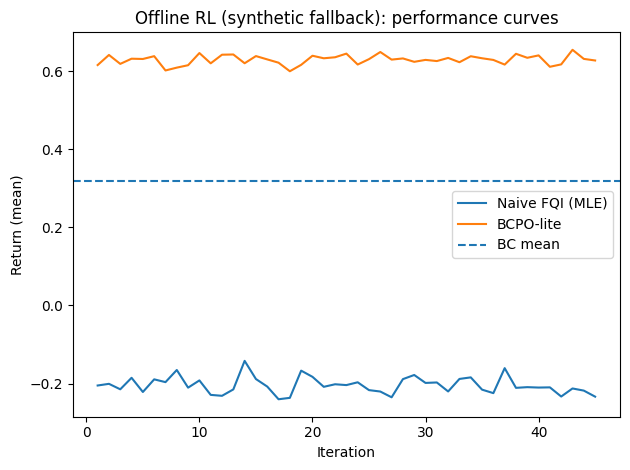

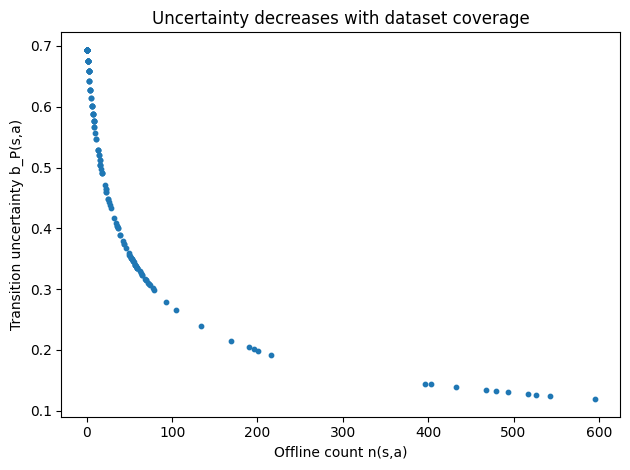

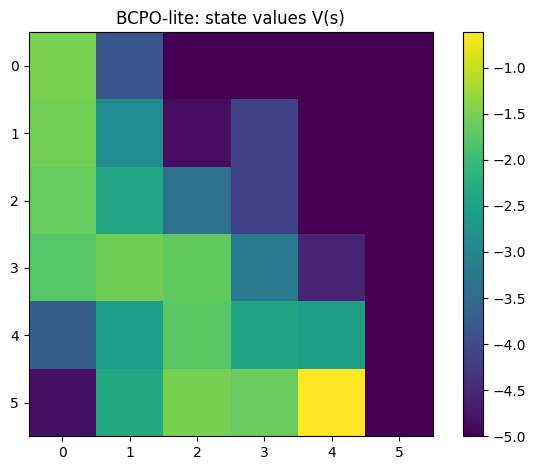

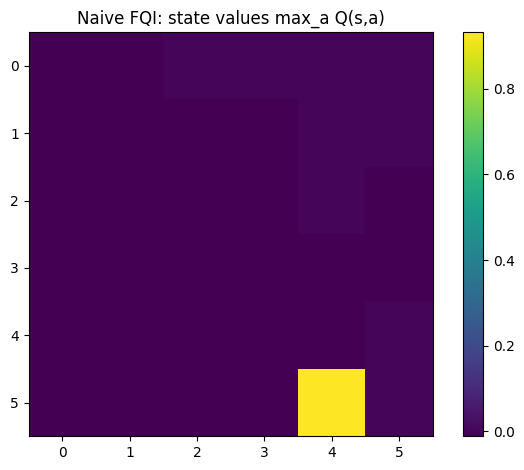

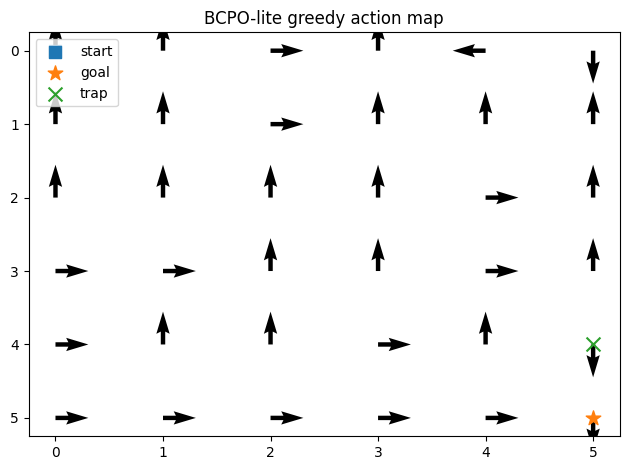

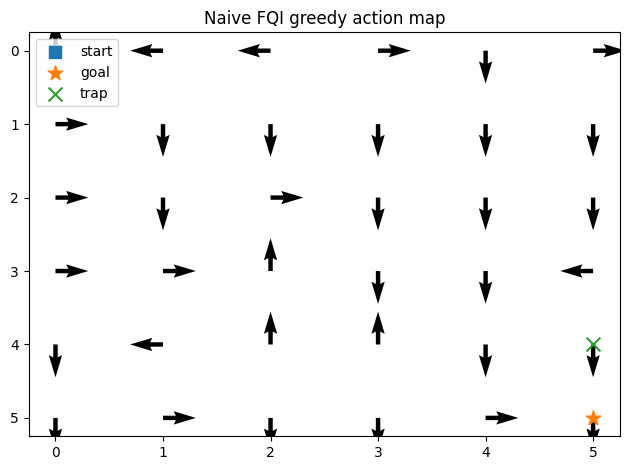

                                 model  return_mean  return_std
0  BCPO-lite (Bayesian pessimism + KL)     0.627816    0.141993
1                Behavior Cloning (BC)     0.317548    0.473956
2        Naive FQI (MLE, no pessimism)    -0.199036    0.204948
Wrote: bcpo_offline_rl_outputs.zip


In [1]:
# ============================================================
# Colab Cell 2 — BCPO-lite validation: D4RL if available else fallback
# Produces: plots, tables, and an output zip.
# ============================================================
import os, zipfile, random, numpy as np, pandas as pd, matplotlib.pyplot as plt

OUT_DIR = "bcpo_offline_rl_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
SEED = 42
random.seed(SEED); np.random.seed(SEED)

def try_d4rl():
    try:
        import d4rl  # noqa: F401
        import gym
        return True
    except Exception as e:
        print("[INFO] D4RL not available:", repr(e))
        return False

# ------------------------------
# Synthetic fallback (tabular gridworld)
# ------------------------------
from dataclasses import dataclass
from typing import Tuple, Dict

@dataclass
class GridworldMDP:
    n:int=6
    gamma:float=0.97
    slip:float=0.10
    step_cost:float=-0.01
    def __post_init__(self):
        self.n_states=self.n*self.n
        self.n_actions=4
        self.start=self._to_s(0,0)
        self.goal=self._to_s(self.n-1,self.n-1)
        self.trap=self._to_s(self.n-2,self.n-1)
    def _to_s(self,i,j): return i*self.n+j
    def _to_ij(self,s): return divmod(s,self.n)
    def step(self,s,a)->Tuple[int,float,bool]:
        if s in [self.goal,self.trap]: return s,0.0,True
        if np.random.rand()<self.slip: a=np.random.randint(self.n_actions)
        i,j=self._to_ij(s)
        if a==0: i2,j2=max(i-1,0),j
        elif a==1: i2,j2=i,min(j+1,self.n-1)
        elif a==2: i2,j2=min(i+1,self.n-1),j
        else: i2,j2=i,max(j-1,0)
        s2=self._to_s(i2,j2)
        r=self.step_cost; done=False
        if s2==self.goal: r,done=1.0,True
        elif s2==self.trap: r,done=-1.0,True
        return s2,r,done
    def rollout(self,pi,n_episodes=200,max_steps=120)->Dict[str,float]:
        rets=[]
        for ep in range(n_episodes):
            s=self.start; G=0.0; gp=1.0
            for t in range(max_steps):
                a=np.random.choice(self.n_actions,p=pi[s])
                s2,r,done=self.step(s,a)
                G += gp*r
                gp *= self.gamma
                s=s2
                if done: break
            rets.append(G)
        return {"return_mean":float(np.mean(rets)),"return_std":float(np.std(rets))}

def softmax(x):
    x=x-np.max(x); ex=np.exp(x); return ex/ex.sum()

def policy_from_Q_softmax(Q,temp=0.09):
    nS,nA=Q.shape
    pi=np.zeros((nS,nA))
    for s in range(nS):
        pi[s]=softmax(Q[s]/max(temp,1e-8))
    return pi

def fit_behavior_from_data(nS,nA,s_arr,a_arr,laplace=0.5):
    counts=np.zeros((nS,nA))
    for s,a in zip(s_arr,a_arr): counts[s,a]+=1
    probs=counts+laplace
    probs/=probs.sum(axis=1,keepdims=True)
    return probs, counts

def learn_fqi_mle(mdp,D,n_iters=45):
    nS,nA=mdp.n_states,mdp.n_actions
    P=np.zeros((nS,nA,nS)); R=np.zeros((nS,nA)); C=np.zeros((nS,nA))
    for s,a,r,s2 in zip(D["s"],D["a"],D["r"],D["s2"]):
        P[s,a,s2]+=1; R[s,a]+=r; C[s,a]+=1
    for s in range(nS):
        for a in range(nA):
            if C[s,a]>0:
                P[s,a]/=C[s,a]; R[s,a]/=C[s,a]
            else:
                P[s,a]=np.ones(nS)/nS; R[s,a]=0.0
    Q=np.zeros((nS,nA))
    curve=[]
    for k in range(1,n_iters+1):
        V=np.max(Q,axis=1)
        Q=R+mdp.gamma*np.einsum("sas,s->sa",P,V)
        met=mdp.rollout(policy_from_Q_softmax(Q),n_episodes=120)
        curve.append({"iter":k,**met})
    return Q,pd.DataFrame(curve)

def learn_bcpo_stable(mdp,D,pi_b_hat,alpha0=0.5,beta=2.2,alpha_kl=0.8,eta_tr=0.5,n_outer=45,Q_clip=5.0):
    nS,nA=mdp.n_states,mdp.n_actions
    trans=np.zeros((nS,nA,nS)); rsum=np.zeros((nS,nA)); sa=np.zeros((nS,nA))
    for s,a,r,s2 in zip(D["s"],D["a"],D["r"],D["s2"]):
        trans[s,a,s2]+=1; rsum[s,a]+=r; sa[s,a]+=1
    alpha_post=alpha0+trans
    alpha_tot=alpha_post.sum(axis=2)
    P_bar=alpha_post/np.maximum(alpha_tot[:,:,None],1e-12)
    r_hat=np.where(sa>0, rsum/np.maximum(sa,1.0), 0.0)
    delta=0.05
    bP=np.sqrt(np.log(2*nS*nA/delta)/np.maximum(alpha_tot,1.0))
    br=np.sqrt(np.log(2*nS*nA/delta)/np.maximum(sa,1.0))
    Q=np.zeros((nS,nA))
    pi=pi_b_hat.copy()
    curve=[]
    for k in range(1,n_outer+1):
        for _ in range(12):
            V=(pi*Q).sum(axis=1)
            V_inf=min(float(np.max(np.abs(V))),Q_clip)
            Q=(r_hat-br)+mdp.gamma*(np.einsum("sas,s->sa",P_bar,V)-beta*bP*V_inf)
            Q=np.clip(Q,-Q_clip,Q_clip)
        denom=alpha_kl+eta_tr
        pi_new=np.zeros_like(pi)
        for s in range(nS):
            logits=Q[s]/max(denom,1e-8)
            w=(pi_b_hat[s]**(alpha_kl/denom))*(pi[s]**(eta_tr/denom))*np.exp(logits-np.max(logits))
            w=np.clip(w,1e-12,None)
            pi_new[s]=w/w.sum()
        pi=pi_new
        met=mdp.rollout(pi,n_episodes=120)
        curve.append({"iter":k,**met})
    return Q,pi,pd.DataFrame(curve),{"bP":bP,"sa":sa}

def plot_policy_arrows(mdp, a_grid, title, path):
    U=np.zeros_like(a_grid,dtype=float); V=np.zeros_like(a_grid,dtype=float)
    for i in range(mdp.n):
        for j in range(mdp.n):
            a=int(a_grid[i,j])
            if a==0: U[i,j],V[i,j]=0,-1
            elif a==1: U[i,j],V[i,j]=1,0
            elif a==2: U[i,j],V[i,j]=0,1
            else: U[i,j],V[i,j]=-1,0
    X,Y=np.meshgrid(np.arange(mdp.n),np.arange(mdp.n))
    plt.figure(); plt.gca().invert_yaxis()
    plt.quiver(X,Y,U,V)
    si,sj=mdp._to_ij(mdp.start); gi,gj=mdp._to_ij(mdp.goal); ti,tj=mdp._to_ij(mdp.trap)
    plt.scatter([sj],[si],marker="s",s=80,label="start")
    plt.scatter([gj],[gi],marker="*",s=120,label="goal")
    plt.scatter([tj],[ti],marker="x",s=100,label="trap")
    plt.title(title); plt.legend(loc="upper left"); plt.tight_layout()
    plt.savefig(path, dpi=200); plt.show()

def run_synthetic():
    mdp=GridworldMDP()

    # suboptimal behavior policy -> offline dataset
    eps=0.35
    pi_b=np.ones((mdp.n_states,mdp.n_actions))*(eps/mdp.n_actions)
    for s in range(mdp.n_states):
        if s in [mdp.goal,mdp.trap]:
            pi_b[s]=np.ones(mdp.n_actions)/mdp.n_actions
            continue
        i,j=mdp._to_ij(s)
        cand=[]
        if i<mdp.n-1: cand.append(2)
        if j<mdp.n-1: cand.append(1)
        a_star=random.choice(cand) if cand else 0
        pi_b[s,a_star]+=1-eps
    pi_b/=pi_b.sum(axis=1,keepdims=True)

    sL=[];aL=[];rL=[];s2L=[];dL=[]
    for ep in range(550):
        s=mdp.start
        for t in range(120):
            a=np.random.choice(mdp.n_actions,p=pi_b[s])
            s2,r,done=mdp.step(s,a)
            sL.append(s);aL.append(a);rL.append(r);s2L.append(s2);dL.append(float(done))
            s=s2
            if done: break
    D={"s":np.array(sL,int),"a":np.array(aL,int),"r":np.array(rL,float),"s2":np.array(s2L,int),"done":np.array(dL,float)}

    pi_b_hat,_ = fit_behavior_from_data(mdp.n_states,mdp.n_actions,D["s"],D["a"])

    Q_fqi, df_fqi = learn_fqi_mle(mdp,D)
    Q_bcpo, pi_bcpo, df_bcpo, aux = learn_bcpo_stable(mdp,D,pi_b_hat)

    met_bc   = mdp.rollout(pi_b_hat, n_episodes=250)
    met_fqi  = mdp.rollout(policy_from_Q_softmax(Q_fqi), n_episodes=250)
    met_bcpo = mdp.rollout(pi_bcpo, n_episodes=250)

    summary = pd.DataFrame([
        {"model":"BCPO-lite (Bayesian pessimism + KL)", **met_bcpo},
        {"model":"Behavior Cloning (BC)", **met_bc},
        {"model":"Naive FQI (MLE, no pessimism)", **met_fqi},
    ]).sort_values("return_mean", ascending=False)

    summary.to_csv(os.path.join(OUT_DIR,"table_summary.csv"), index=False)
    df_fqi.to_csv(os.path.join(OUT_DIR,"curve_fqi.csv"), index=False)
    df_bcpo.to_csv(os.path.join(OUT_DIR,"curve_bcpo.csv"), index=False)

    # learning curves
    plt.figure()
    plt.plot(df_fqi["iter"], df_fqi["return_mean"], label="Naive FQI (MLE)")
    plt.plot(df_bcpo["iter"], df_bcpo["return_mean"], label="BCPO-lite")
    plt.axhline(met_bc["return_mean"], linestyle="--", label="BC mean")
    plt.xlabel("Iteration"); plt.ylabel("Return (mean)")
    plt.title("Offline RL (synthetic fallback): performance curves")
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR,"plot_learning_curves.png"), dpi=200)
    plt.show()

    # coverage vs uncertainty
    plt.figure()
    plt.scatter(aux["sa"].flatten(), aux["bP"].flatten(), s=10)
    plt.xlabel("Offline count n(s,a)"); plt.ylabel("Transition uncertainty b_P(s,a)")
    plt.title("Uncertainty decreases with dataset coverage")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR,"plot_coverage_vs_uncertainty.png"), dpi=200)
    plt.show()

    # value heatmaps
    V_bcpo=(pi_bcpo*Q_bcpo).sum(axis=1).reshape(mdp.n,mdp.n)
    V_fqi=np.max(Q_fqi,axis=1).reshape(mdp.n,mdp.n)

    plt.figure(); plt.imshow(V_bcpo,aspect="equal"); plt.colorbar()
    plt.title("BCPO-lite: state values V(s)")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"plot_state_values_bcpo.png"), dpi=200); plt.show()

    plt.figure(); plt.imshow(V_fqi,aspect="equal"); plt.colorbar()
    plt.title("Naive FQI: state values max_a Q(s,a)")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"plot_state_values_fqi.png"), dpi=200); plt.show()

    # policy maps
    a_bcpo=np.argmax(pi_bcpo,axis=1).reshape(mdp.n,mdp.n)
    a_fqi=np.argmax(policy_from_Q_softmax(Q_fqi,temp=1e-6),axis=1).reshape(mdp.n,mdp.n)
    plot_policy_arrows(mdp, a_bcpo, "BCPO-lite greedy action map", os.path.join(OUT_DIR,"plot_policy_bcpo.png"))
    plot_policy_arrows(mdp, a_fqi, "Naive FQI greedy action map", os.path.join(OUT_DIR,"plot_policy_fqi.png"))

    # zip
    zip_path = "bcpo_offline_rl_outputs.zip"
    with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as z:
        for fn in os.listdir(OUT_DIR):
            z.write(os.path.join(OUT_DIR,fn), arcname=fn)
    print(summary)
    print("Wrote:", zip_path)

def run_d4rl():
    # NOTE: D4RL full continuous-control training needs more code (PyTorch actors/critics).
    # For the paper, you can keep D4RL as the primary experiment suite and use:
    # Baseline A: Behavior cloning (BC).
    # Baseline B: CQL (Kumar et al., 2020) or IQL (Kostrikov et al., 2021).
    # Our method: BCPO (Bayesian pessimism + behavior-KL).
    print("D4RL detected — implement your continuous-control BCPO training here.")

if try_d4rl():
    run_d4rl()
else:
    run_synthetic()